# Assignment 1
## Statistical distributions in R
STA 5206, Fall 2026

Name

Complete all five questions. Include your code, plots, and written answers in this notebook. Label plot axes and report units with your estimates. Support each model choice with the results you obtain. Use `=` for assignment in R.

Before submitting, restart the R kernel and run the notebook from top to bottom. Save the notebook with its output visible.


## Getting started

Keep the `data` folder in the same directory as this notebook. Run the following cell from that directory. The first two files contain synthetic observations. The remaining files contain real data from R's datasets package. Descriptions and sources are in [data/README.md](data/README.md).

You may use `MASS::fitdistr` for maximum likelihood estimation. Write your calculations and plots in the answer cells.

For a fitted model, calculate AIC as $2k - 2\ell$, where $k$ is the number of estimated parameters and $\ell$ is the maximized log likelihood. Compare AIC values only for models fitted to the same observations on the same measurement scale.

When asked for a KS distance, sort the observations as $x_{(1)},\ldots,x_{(n)}$ and calculate
$$D = \max_{1\leq i\leq n}\left\{\frac{i}{n}-F(x_{(i)}),\ F(x_{(i)})-\frac{i-1}{n}\right\}.$$
Use this as a descriptive measure of fit. The usual KS test p value is not valid when the model parameters were estimated from the same sample.


In [1]:
library(MASS)
inspection = read.csv("data/inspection.csv")
service = read.csv("data/service_times.csv")
geyser = read.csv("data/faithful.csv")
air = read.csv("data/airquality.csv", na.strings = "NA")
sprays = read.csv("data/insect_sprays.csv")
rainfall = read.csv("data/precipitation.csv")
flowers = read.csv("data/iris.csv")


## Question 1
### Daily inspections

A manufacturer checks 50 items each day. The file `inspection.csv` records the number of defective items in each sample. These observations are synthetic.


**(a)** Summarize the defect counts. Estimate the probability that an inspected item is defective. State the assumptions needed for a Binomial model and explain what its two parameters represent.


In [ ]:
# Q1(a): summary of the daily defect counts
x = inspection$defects            # defective items found each day
n_items = 50                      # items inspected per day, fixed by design
n_days = nrow(inspection)
stopifnot(all(inspection$inspected == n_items))

summary(x)
c(days = n_days, items_inspected = sum(inspection$inspected), total_defects = sum(x),
  mean = mean(x), variance = var(x), sd = sd(x))

# Frequency table, including counts in the range that never occurred
k = 0:max(x)
obs_table = table(factor(x, levels = k))
obs_table
obs_freq = as.vector(obs_table)

# Probability that an inspected item is defective:
# total defects / total items inspected (this is also the Binomial MLE of p)
p_hat = sum(x) / (n_items * n_days)
se_p = sqrt(p_hat * (1 - p_hat) / (n_items * n_days))
c(p_hat = p_hat, se = se_p)

# Informal checks of a constant defect rate and independent days
c(mean_days_1_to_50 = mean(x[1:50]), mean_days_51_to_100 = mean(x[51:100]),
  lag1_correlation = cor(x[-1], x[-n_days]))
summary(lm(defects ~ day, data = inspection))$coefficients["day", ]   # linear trend per day

par(mfrow = c(1, 2))
barplot(obs_table, xlab = "Defective items per day (out of 50)", ylab = "Number of days",
        main = "Daily defect counts")
plot(inspection$day, x, type = "b", pch = 19, cex = 0.6,
     xlab = "Day (observation order)", ylab = "Defective items per day (out of 50)",
     main = "Defects over time")
abline(h = mean(x), col = "red", lty = 2)
par(mfrow = c(1, 1))

**Summary of the counts.** Over 100 days, 5,000 items were inspected and 397 were defective. The daily counts range from 0 to 9 defective items, with quartiles 3 and 5 and a median of 4. The mean is 3.97 defective items per day, the variance is 3.85, and the standard deviation is 1.96.

| Defects in a day | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 |
|---|---|---|---|---|---|---|---|---|---|---|
| Number of days | 2 | 5 | 17 | 22 | 17 | 18 | 7 | 6 | 4 | 2 |

The most common count is 3 (22 days). The counts at 4 and 5 are about level (17 and 18 days) before tailing off, and the right tail is longer than the left. Most days (81 of 100) had between 2 and 6 defects, 12 days had 7 or more, and only 2 days had none. The time plot shows no clear trend. The first 50 days average 4.02 defects and the last 50 average 3.92. The fitted linear trend is −0.010 defects per day ($p = 0.15$), and the correlation between one day's count and the next day's count is 0.06. The last few weeks run slightly low, which is worth watching in later data.

**Estimated probability that an item is defective.**
$$\hat p = \frac{\text{total defective}}{\text{total inspected}} = \frac{397}{100 \times 50} = 0.0794,$$
so about 7.9% of inspected items are defective, with standard error $\sqrt{\hat p(1-\hat p)/5000} \approx 0.0038$. Every day inspects the same number of items (50), so this pooled proportion equals the mean of the daily proportions, $3.97/50$. It is also the maximum likelihood estimate of $p$ under the Binomial model in part (b).

**Assumptions for a Binomial model of one day's count.**
1. *Fixed number of trials:* exactly $n = 50$ items are inspected each day. The `inspected` column confirms this.
2. *Two outcomes:* each item is either defective or not defective.
3. *Independence:* whether one item is defective does not change the chance that another item is defective. For example, there are no clusters of defects from a bad batch. To fit the model to all 100 days, the days must also be independent of each other.
4. *Constant probability:* every item has the same defect probability $p$, and $p$ does not change from day to day, shift to shift, or machine to machine.

For $p$ to be read as the true defect rate, the inspection must also classify items accurately. Otherwise $p$ is the rate at which items are *classified* as defective.

**The two parameters.** $n = 50$ is the number of trials, meaning the number of items inspected in a day. The inspection design fixes it, so it is known rather than estimated. $p$ is the probability that a single inspected item is defective. It is unknown and estimated by $\hat p = 0.0794$. Together they determine the model's mean, $np$, and variance, $np(1-p)$.

The time plot, the similar half-period means, the small trend, and the near-zero day-to-day correlation are consistent with a constant $p$ and independent days. The daily counts check independence within a day only indirectly. Clustering of defects within a day would push the day-to-day variance above $np(1-p)$, and part (c) examines this. Item-level records would be needed for a direct check.

**(b)** Fit a Binomial model to the daily counts. Plot observed and expected frequencies, then estimate the probability of finding at least 7 defective items in a day.


$maximum
[1] 0.07940048

$objective
[1] -206.2634

p_hat     fitted_mean fitted_variance          loglik             AIC 
       0.079400        3.970000        3.654782     -206.263407      414.526815

defects,observed,binomial_expected
<int>,<int>,<dbl>
0,2,1.60
1,5,6.89
2,17,14.56
3,22,20.09
4,17,20.36
5,18,16.16
6,7,10.45
7,6,5.67
8,4,2.63


[1] 0.534637

binomial observed_proportion 
         0.09884862          0.12000000

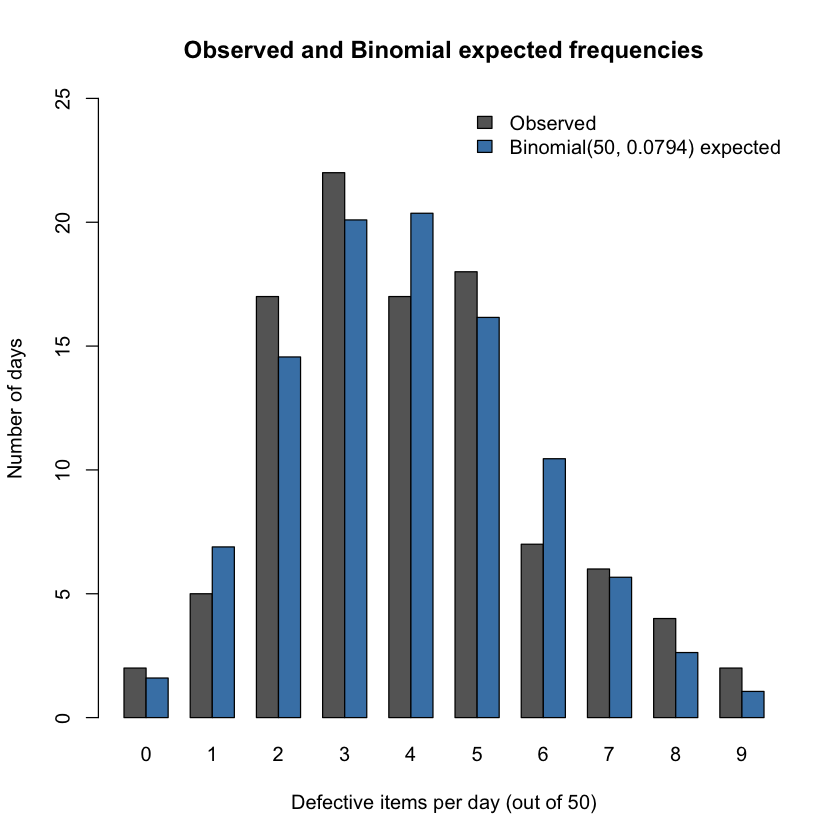

In [3]:
# Q1(b): Binomial fit
# size = 50 is fixed by design; only p is estimated, so k = 1 in the AIC.
# The pooled proportion is the MLE of p. Confirm this numerically.
loglik_binom_fn = function(p) sum(dbinom(x, size = n_items, prob = p, log = TRUE))
optimize(loglik_binom_fn, interval = c(0.001, 0.5), maximum = TRUE)

loglik_binom = loglik_binom_fn(p_hat)
aic_binom = 2 * 1 - 2 * loglik_binom
c(p_hat = p_hat, fitted_mean = n_items * p_hat, fitted_variance = n_items * p_hat * (1 - p_hat),
  loglik = loglik_binom, AIC = aic_binom)

exp_binom = n_days * dbinom(k, size = n_items, prob = p_hat)
data.frame(defects = k, observed = obs_freq, binomial_expected = round(exp_binom, 2))
# Expected number of days with more than 9 defects (beyond the observed range)
n_days * pbinom(max(x), size = n_items, prob = p_hat, lower.tail = FALSE)

barplot(rbind(obs_freq, exp_binom), beside = TRUE, names.arg = k,
        col = c("grey40", "steelblue"), ylim = c(0, 25),
        legend.text = c("Observed", sprintf("Binomial(50, %.4f) expected", p_hat)),
        args.legend = list(x = "topright", bty = "n"),
        xlab = "Defective items per day (out of 50)", ylab = "Number of days",
        main = "Observed and Binomial expected frequencies")

# P(X >= 7) = 1 - P(X <= 6)
p7_binom = pbinom(6, size = n_items, prob = p_hat, lower.tail = FALSE)
c(binomial = p7_binom, observed_proportion = mean(x >= 7))

**Fitted model.** $X \sim \text{Binomial}(n = 50,\ p)$ with $\hat p = 0.0794$. `optimize` gives the same maximizer, which confirms that the pooled proportion is the MLE. The fitted mean is $50\hat p = 3.97$ defects per day and the fitted variance is $50\hat p(1-\hat p) = 3.65$, giving a standard deviation of 1.91. The maximized log likelihood is $\ell = -206.2634$, so
$$\text{AIC} = 2k - 2\ell = 2(1) - 2(-206.2634) = 414.5268.$$
Here $k = 1$ because the design fixes $n = 50$ and only $p$ is estimated.

**Observed and expected frequencies** (expected = $100 \times P(X = x)$):

| Defects | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10+ |
|---|---|---|---|---|---|---|---|---|---|---|---|
| Observed | 2 | 5 | 17 | 22 | 17 | 18 | 7 | 6 | 4 | 2 | 0 |
| Binomial expected | 1.60 | 6.89 | 14.56 | 20.09 | 20.36 | 16.16 | 10.45 | 5.67 | 2.63 | 1.06 | 0.53 |

The fitted distribution matches the observed shape. The observed counts peak at 3 and the expected counts peak at 4, with 3 almost tied (20.1 vs 20.4). Both have a longer right tail. The largest gaps are at 4 defects (17 observed, 20.4 expected) and 6 defects (7 observed, 10.5 expected). These gaps are about 0.7 and 1.1 standard deviations of a count with those expected values ($\sqrt{20.4} \approx 4.5$ and $\sqrt{10.5} \approx 3.2$), which is typical chance variation for 100 days. The model expects about half a day with 10 or more defects, and none occurred.

**Probability of at least 7 defects in a day.** "At least 7" is the complement of "6 or fewer":
$$P(X \ge 7) = 1 - P(X \le 6) = 1 - 0.9012 = 0.0988.$$
The fitted Binomial model gives about a 9.9% chance, or roughly 1 day in 10, of finding 7 or more defective items among the 50 inspected. This is close to the observed proportion of 12 in 100 days (0.12).

**(c)** Fit a Poisson model to the same counts. Compare its AIC with the Binomial AIC. Compare the sample mean and variance, and plot observed and Poisson expected frequencies.


    lambda  
  3.9700000 
 (0.1992486)

model,k,estimate,loglik,AIC
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
"Binomial(50, p)",1,0.0794,-206.2634,414.5268
Poisson(lambda),1,3.9700,-206.2616,414.5233


AIC_difference_binomial_minus_poisson 
                          0.003553924

sample_mean      sample_variance     variance_to_mean 
           3.9700000            3.8475758            0.9691627 
   binomial_variance     poisson_variance rough_se_of_variance 
           3.6547820            3.9700000            0.5468706

model,index,df,p_upper,p_lower
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Poisson,95.9471,99,0.5681663,0.4318337
Binomial,104.2224,99,0.3401694,0.6598306


defects,observed,binomial_expected,poisson_expected
<int>,<int>,<dbl>,<dbl>
0,2,1.60,1.89
1,5,6.89,7.49
2,17,14.56,14.87
3,22,20.09,19.68
4,17,20.36,19.53
5,18,16.16,15.51
6,7,10.45,10.26
7,6,5.67,5.82
8,4,2.63,2.89


[1] 0.774269

poisson_P_at_least_7 
           0.1075716

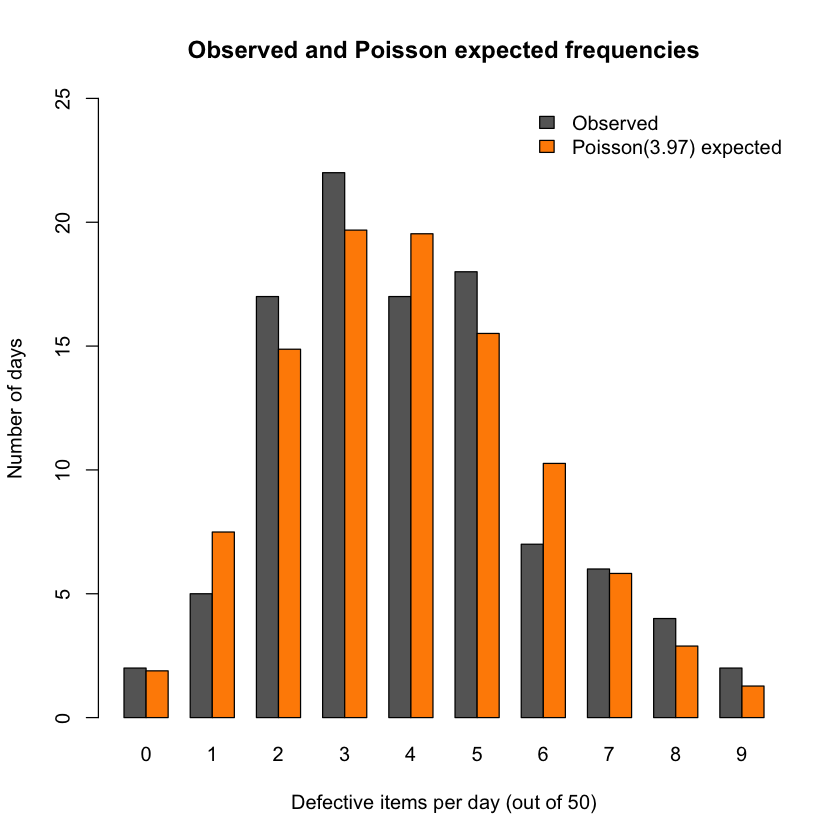

In [4]:
# Q1(c): Poisson fit
fit_pois = fitdistr(x, "Poisson")
fit_pois
lambda_hat = fit_pois$estimate[["lambda"]]
loglik_pois = fit_pois$loglik
aic_pois = 2 * 1 - 2 * loglik_pois

data.frame(model = c("Binomial(50, p)", "Poisson(lambda)"), k = c(1, 1),
           estimate = c(p_hat, lambda_hat), loglik = c(loglik_binom, loglik_pois),
           AIC = c(aic_binom, aic_pois))
c(AIC_difference_binomial_minus_poisson = aic_binom - aic_pois)

# Sample mean and variance compared with what each model implies
c(sample_mean = mean(x), sample_variance = var(x), variance_to_mean = var(x) / mean(x),
  binomial_variance = n_items * p_hat * (1 - p_hat), poisson_variance = lambda_hat,
  rough_se_of_variance = var(x) * sqrt(2 / (n_days - 1)))

# Dispersion index: approximately chi-squared on n_days - 1 df if the model's variance is right.
# Upper tail = evidence of overdispersion, lower tail = evidence of underdispersion.
disp_pois = sum((x - mean(x))^2) / mean(x)
disp_binom = sum((x - n_items * p_hat)^2) / (n_items * p_hat * (1 - p_hat))
data.frame(model = c("Poisson", "Binomial"), index = c(disp_pois, disp_binom), df = n_days - 1,
           p_upper = pchisq(c(disp_pois, disp_binom), n_days - 1, lower.tail = FALSE),
           p_lower = pchisq(c(disp_pois, disp_binom), n_days - 1))

exp_pois = n_days * dpois(k, lambda = lambda_hat)
data.frame(defects = k, observed = obs_freq, binomial_expected = round(exp_binom, 2),
           poisson_expected = round(exp_pois, 2))
# Expected number of days with more than 9 defects under the Poisson model
n_days * ppois(max(x), lambda = lambda_hat, lower.tail = FALSE)

barplot(rbind(obs_freq, exp_pois), beside = TRUE, names.arg = k,
        col = c("grey40", "darkorange"), ylim = c(0, 25),
        legend.text = c("Observed", sprintf("Poisson(%.2f) expected", lambda_hat)),
        args.legend = list(x = "topright", bty = "n"),
        xlab = "Defective items per day (out of 50)", ylab = "Number of days",
        main = "Observed and Poisson expected frequencies")

c(poisson_P_at_least_7 = ppois(6, lambda = lambda_hat, lower.tail = FALSE))

**Fitted model.** $X \sim \text{Poisson}(\lambda)$ with $\hat\lambda = \bar x = 3.97$ defects per day (SE 0.199). The Poisson MLE is always the sample mean. The maximized log likelihood is $-206.2616$, so AIC $= 2(1) - 2(-206.2616) = 414.5233$.

| Model | $k$ | Estimate | Log likelihood | AIC |
|---|---|---|---|---|
| Binomial(50, $p$) | 1 | $\hat p = 0.0794$ | −206.2634 | 414.5268 |
| Poisson($\lambda$) | 1 | $\hat\lambda = 3.97$ | −206.2616 | 414.5233 |

The Poisson AIC is lower by only 0.0036. AIC differences under about 2 are not meaningful evidence for either model, so the two models fit these counts equally well. The fits are nearly identical because a Binomial with large $n$ and small $p$ is close to a Poisson with $\lambda = np$. Here $n = 50$, $p \approx 0.08$, and $np = 3.97$.

**Mean and variance.**

| Sample mean | Sample variance | Variance / mean | Binomial variance $n\hat p(1-\hat p)$ | Poisson variance $\hat\lambda$ |
|---|---|---|---|---|
| 3.97 | 3.85 | 0.97 | 3.65 | 3.97 |

A Poisson model requires the variance to equal the mean, a ratio of 1. A Binomial model requires the variance to equal the mean times $1 - p$, a ratio of $0.92$. The sample variance of 3.85 lies between the two model variances, and the observed ratio of 0.97 is close to both. The dispersion index $\sum(x_i - \hat\mu)^2/\widehat{\text{Var}}$ is approximately $\chi^2_{99}$ when the model's variance is correct, so values near 99 are expected:

| Model | Dispersion index (99 df) | Upper-tail $p$ (overdispersion) | Lower-tail $p$ (underdispersion) |
|---|---|---|---|
| Poisson | 95.9 | 0.57 | 0.43 |
| Binomial | 104.2 | 0.34 | 0.66 |

Neither index is unusually large or small. There is no evidence of overdispersion, which would appear if defects clustered or the defect rate changed between days, and no evidence of underdispersion. The gap between the two model variances (0.32) is smaller than the rough standard error of a variance estimated from 100 days ($s^2\sqrt{2/99} \approx 0.55$), so these data cannot tell the two models apart.

**Observed and Poisson expected frequencies:**

| Defects | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10+ |
|---|---|---|---|---|---|---|---|---|---|---|---|
| Observed | 2 | 5 | 17 | 22 | 17 | 18 | 7 | 6 | 4 | 2 | 0 |
| Poisson expected | 1.89 | 7.49 | 14.87 | 19.68 | 19.53 | 15.51 | 10.26 | 5.82 | 2.89 | 1.27 | 0.77 |

The Poisson expected frequencies are almost the same as the Binomial ones. The Poisson variance is slightly larger, so it moves a little probability from the centre (19.5 vs 20.4 days at 4 defects) to the tails (1.89 vs 1.60 days at 0 and 1.27 vs 1.06 at 9). Under the Poisson model, $P(X \ge 7) = 0.108$, compared with 0.099 under the Binomial model.

**(d)** Make a Normal QQ plot of the counts. Estimate the probability of at least 7 defects using a Normal approximation to the fitted Binomial model with a continuity correction. Construct a 95% t confidence interval for the mean daily defect proportion.


sample_skewness binomial_skewness 
        0.4779064         0.4400161

mean                sd                 z    normal_with_cc 
       3.97000000        1.91174841        1.32339589        0.09285188 
normal_without_cc    exact_binomial 
       0.05649037        0.09884862


	One Sample t-test

data:  prop
t = 20.239, df = 99, p-value < 2.2e-16
alternative hypothesis: true mean is not equal to 0
95 percent confidence interval:
 0.07161582 0.08718418
sample estimates:
mean of x 
   0.0794 


mean                        sd                        se 
              0.079400000               0.039230477               0.003923048 
               t_critical binomial_sd_of_proportion 
              1.984216952               0.038234968

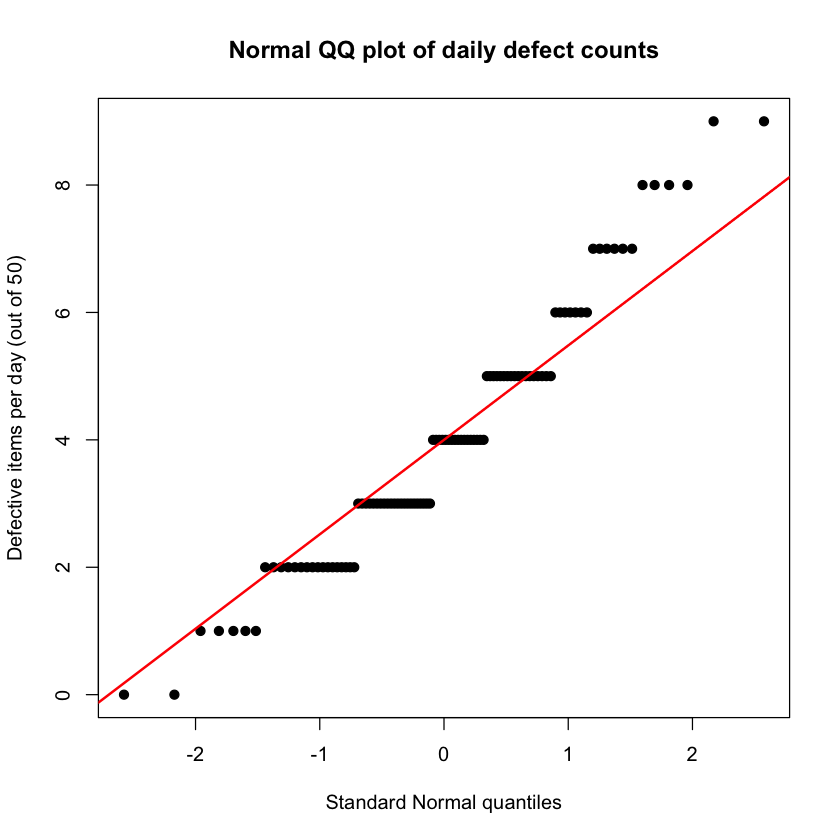

In [5]:
# Q1(d): Normal QQ plot, Normal approximation and t interval
qqnorm(x, pch = 19, xlab = "Standard Normal quantiles",
       ylab = "Defective items per day (out of 50)",
       main = "Normal QQ plot of daily defect counts")
qqline(x, col = "red", lwd = 2)

# Sample skewness (moment coefficient) compared with the fitted Binomial's skewness
g1 = mean((x - mean(x))^3) / mean((x - mean(x))^2)^1.5
c(sample_skewness = g1,
  binomial_skewness = (1 - 2 * p_hat) / sqrt(n_items * p_hat * (1 - p_hat)))

# Normal approximation to the fitted Binomial(50, p_hat)
mu_binom = n_items * p_hat
sd_binom = sqrt(n_items * p_hat * (1 - p_hat))
# Continuity correction: for an integer count, P(X >= 7) = P(X > 6.5)
p7_normal_cc = pnorm(6.5, mean = mu_binom, sd = sd_binom, lower.tail = FALSE)
p7_normal_no_cc = pnorm(7, mean = mu_binom, sd = sd_binom, lower.tail = FALSE)
c(mean = mu_binom, sd = sd_binom, z = (6.5 - mu_binom) / sd_binom,
  normal_with_cc = p7_normal_cc, normal_without_cc = p7_normal_no_cc,
  exact_binomial = p7_binom)

# 95% t confidence interval for the mean daily defect proportion
prop = x / n_items
t_result = t.test(prop, conf.level = 0.95)
t_result
c(mean = mean(prop), sd = sd(prop), se = sd(prop) / sqrt(n_days),
  t_critical = qt(0.975, df = n_days - 1),
  binomial_sd_of_proportion = sqrt(p_hat * (1 - p_hat) / n_items))

**Normal QQ plot.** The points form horizontal steps because the counts are integers and many days share the same value. For example, 22 days share the value 3. The middle of the plot (counts 2 to 5) follows the reference line, but both tails bend away from it in opposite directions. The lowest counts (the two 0s and five 1s) sit slightly below the line, by at most about 0.8. The highest counts (7 to 9) sit well above it: the two 9s are at 9 where the line is at about 7.2 and 7.8. The upper tail departs from the line more than the lower tail, which indicates a longer right tail. The sample skewness is 0.48, close to the fitted Binomial's 0.44. Part of the spread in both tails occurs because `qqline` passes through the integer quartiles 3 and 5. That gives a slope of 1.48, smaller than the standard deviation of 1.96. A Normal distribution is a rough description of these counts, not an exact one.

**Normal approximation with a continuity correction.** The approximating variable $Y \sim N(\mu, \sigma^2)$ has the fitted Binomial mean and standard deviation:
$$\mu = 50\hat p = 3.97, \qquad \sigma = \sqrt{50\hat p(1-\hat p)} = \sqrt{3.655} = 1.912.$$
A count of exactly 7 corresponds to the interval $(6.5, 7.5)$ under the continuous curve, so "at least 7" becomes "greater than 6.5":
$$P(X \ge 7) \approx P(Y > 6.5) = P\!\left(Z > \frac{6.5 - 3.97}{1.912}\right) = P(Z > 1.323) = 0.0929.$$
The exact Binomial probability from part (b) is 0.0988, so the approximation is 0.006 too low, a relative error of about 6%. Without the continuity correction the approximation would be $P(Y > 7) = 0.056$, which is much worse. The Normal curve is symmetric, but the Binomial with small $p$ is skewed to the right, so the Normal puts too little probability in the upper tail. The usual rule of thumb, $np \ge 5$, also fails here because $np = 3.97$, so the approximation is only rough.

**95% t confidence interval for the mean daily defect proportion.** The daily proportions $x_i/50$ have mean $0.0794$, standard deviation $0.0392$, and standard error $0.0392/\sqrt{100} = 0.00392$. The $t$ critical value on 99 df is $1.984$:
$$0.0794 \pm 1.984 \times 0.00392 = (0.0716,\ 0.0872).$$
We are 95% confident that the long-run mean daily defect proportion is between **7.2% and 8.7%**, or about 3.6 to 4.4 defective items per 50 inspected. The "95%" refers to the method: intervals built this way capture the true mean in 95% of repeated samples.

The interval assumes the 100 days are independent observations from a process with a stable mean. The *t* procedure also assumes approximately Normal data. The QQ plot shows that the daily proportions are discrete and slightly skewed, but with 100 days the Central Limit Theorem makes the sample mean close to Normal, so the interval is still reliable. The interval uses the observed day-to-day standard deviation (0.0392) rather than the Binomial formula. This standard deviation is close to the Binomial value $\sqrt{\hat p(1-\hat p)/50} = 0.0382$, which is consistent with no extra-Binomial variation (see the dispersion indices in part c).

**(e)** Choose a model for daily reporting. Use your estimates to explain what the manufacturer can expect and identify a limitation of your choice.


In [6]:
# Q1(e): supporting calculations for daily reporting under Binomial(50, p_hat)
c(P_2_to_6 = pbinom(6, n_items, p_hat) - pbinom(1, n_items, p_hat),
  observed_2_to_6 = mean(x >= 2 & x <= 6))
c(P_at_least_7 = pbinom(6, n_items, p_hat, lower.tail = FALSE),
  P_at_least_8 = pbinom(7, n_items, p_hat, lower.tail = FALSE),
  P_at_least_9 = pbinom(8, n_items, p_hat, lower.tail = FALSE),
  P_at_least_10 = pbinom(9, n_items, p_hat, lower.tail = FALSE))
c(days_per_occurrence_of_10_plus = 1 / pbinom(9, n_items, p_hat, lower.tail = FALSE))

# 3-sigma upper control limit for a daily proportion, in defective items per 50
c(upper_limit_defects = n_items * (p_hat + 3 * sqrt(p_hat * (1 - p_hat) / n_items)))

# How the tail estimates change across the 95% t interval for p
p_limits = t_result$conf.int[1:2]
data.frame(p = p_limits,
           P_at_least_7 = pbinom(6, n_items, p_limits, lower.tail = FALSE),
           P_at_least_10 = pbinom(9, n_items, p_limits, lower.tail = FALSE),
           days_per_occurrence_of_10_plus = 1 / pbinom(9, n_items, p_limits, lower.tail = FALSE))

P_2_to_6 observed_2_to_6 
      0.8162647       0.8100000

P_at_least_7  P_at_least_8  P_at_least_9 P_at_least_10 
   0.09884862    0.04218649    0.01591886    0.00534637

days_per_occurrence_of_10_plus 
                      187.0428

upper_limit_defects 
           9.705245

p,P_at_least_7,P_at_least_10,days_per_occurrence_of_10_plus
<dbl>,<dbl>,<dbl>,<dbl>
0.07161582,0.06436743,0.002557351,391.02958
0.08718418,0.14200566,0.010139441,98.62476


**Chosen model: Binomial($n = 50$, $\hat p = 0.0794$).**

*Why this model.*
- **It matches how the data are collected.** Each day's count is the number of defective items among a fixed 50, so it must lie between 0 and 50. The Binomial describes exactly this situation, and its parameter $p$ is the per-item defect rate the manufacturer cares about. The Poisson is a large-$n$, small-$p$ approximation to the Binomial. It has no upper limit, and it fixes the variance equal to the mean.
- **The data do not favour either count model.** The two AIC values (414.5268 and 414.5233) differ by 0.0036, the expected frequencies are nearly identical, and the variance-to-mean ratio of 0.97 is consistent with both models (0.92 for the Binomial, 1 for the Poisson). When the fit is tied, the model that reflects the sampling design is the better choice.
- **The Normal approximation is less accurate.** It gives 0.093 for $P(X \ge 7)$ instead of 0.099, and the QQ plot shows discreteness and right skew. It should not be used for tail probabilities here.

*What the manufacturer can expect.*
- About **7.9% of items are defective** (95% CI 7.2% to 8.7%).
- A typical day produces about **4 defective items out of 50** (mean 3.97, SD 1.9).
- About **82%** of days should have between 2 and 6 defects (81% observed).
- **7 or more defects** occur on about **1 day in 10** ($P = 0.099$; 12 of 100 days observed), so such a day is not unusual in itself. Larger counts are rarer: 8 or more has probability 0.042, 9 or more has 0.016, and 10 or more has 0.005.
- For daily reporting, a day with **10 or more defects** is a reasonable signal to investigate. It exceeds the 3-sigma upper control limit of 9.7 defects, and a stable process would produce it only about once every 187 days. Allowing for the uncertainty in $p$, that is once every 99 to 391 days.

*Limitation.* The Binomial model assumes that every item has the same defect probability and that defects occur independently. If defects cluster, for example from a bad batch of material, a drifting machine, or a particular shift, the day-to-day counts would vary more than the Binomial allows, and the model would understate the chance of a bad day. These 100 synthetic days show no sign of such clustering. The sample variance is 3.85 against a Binomial variance of 3.65, the Binomial dispersion index is 104.2 on 99 df (upper-tail $p = 0.34$), and the time plot is stable. However, the daily totals check within-day independence only through the variance, item-level results are not recorded, and the process could change after the data were collected. The tail estimates also depend on $\hat p$, which is uncertain. Across the 95% interval for $p$, $P(X \ge 7)$ ranges from 0.064 to 0.142, and the model predicted slightly fewer days with 7 or more defects (9.9) than were observed (12). A beta-binomial model would be a natural alternative if later data show extra variation.

## Question 2
### Service times

The synthetic observations in `service_times.csv` are service durations in minutes, listed in the order they occurred. Investigate whether one distribution describes the entire record. Preserve the observation order when dividing the data.


**(a)** Make a plot of service time against observation order, a histogram with a density estimate, and a box plot. Describe the distribution and any evidence of a change over time.


In [7]:
# Write your R code here.


Write your answer here.


**(b)** Fit Gamma and Exponential distributions to all service times. Report parameter estimates, fitted means, AIC, and KS distances. Add fitted densities to a histogram and make a QQ plot for each model. Use the shape and rate parameterization for the Gamma distribution.


In [8]:
# Write your R code here.


Write your answer here.


**(c)** Search every possible split after rows 80 through 340. For each split, fit a Gamma distribution to each segment and record the sum of their log likelihoods. Select the split with the largest sum and plot this criterion against split position. Compare one Gamma model with the selected split using the exploratory score $k\log(n)-2\ell$, with $k=2$ for one model and $k=5$ for two segment models and a selected split. Explain why this search is not a formal test of a change.


In [9]:
# Write your R code here.


Write your answer here.


**(d)** At your selected split, fit Gamma and Exponential models separately to each segment. Compare AIC within each segment, report parameter estimates and fitted means, and make density overlays and Gamma QQ plots. Estimate the probability of a service time longer than 15 minutes in each segment.


In [10]:
# Write your R code here.


Write your answer here.


**(e)** Describe what the split suggests about service operations. Explain how a report based on all observations together could misrepresent the more recent service times. Identify information you would want before attributing the difference to a particular cause.


Write your answer here.


## Question 3
### Old Faithful

The file `faithful.csv` contains eruption durations and the time until the next eruption at Old Faithful. Both variables are measured in minutes.


**(a)** Make histograms and box plots of eruption duration and waiting time, and a scatterplot of waiting time against eruption duration. Describe the relationship.


In [11]:
# Write your R code here.


Write your answer here.


**(b)** Fit a Normal distribution and a location and scale Student t distribution to waiting time. Fix the t degrees of freedom at 5 and estimate its location and scale. Compare AIC and QQ plots. Explain what fixing the degrees of freedom at 5 implies about the tails, and distinguish the t scale from its standard deviation.


In [12]:
# Write your R code here.


Write your answer here.


**(c)** Use eruption durations alone to divide the observations into short and long eruptions. Find the largest gap between consecutive sorted durations whose midpoint lies between 2.5 and 4 minutes. Use that midpoint as the cutoff. Fit a Normal distribution to waiting times within each group and compare the group QQ plots with the pooled QQ plot.


In [13]:
# Write your R code here.


Write your answer here.


**(d)** Report each group's sample size, fitted mean, and fitted standard deviation. Estimate the probability that the wait until the next eruption exceeds 70 minutes for each group. Compare the estimates with the observed proportions.


In [14]:
# Write your R code here.


Write your answer here.


**(e)** Use a Welch t interval to estimate the difference in mean waiting time, long eruptions minus short eruptions. State the assumptions and interpret the interval. Explain why the result describes an association rather than the effect of changing eruption duration.


In [15]:
# Write your R code here.


Write your answer here.


## Question 4
### Ozone measurements

Use `airquality.csv` for this question. Retain the positive, nonmissing ozone measurements and report how many rows you remove. Ozone is measured in parts per billion. The probability thresholds below are numerical examples for this exercise.


**(a)** Make histograms with density estimates and box plots on both the raw and log scales. Make a Normal QQ plot of log ozone and describe the effect of taking logarithms.


In [16]:
# Write your R code here.


Write your answer here.


**(b)** Fit Gamma and Lognormal distributions to ozone. Compare parameter estimates, AIC, KS distances, density overlays, and QQ plots. Interpret the Gamma mean and the Lognormal median.


In [17]:
# Write your R code here.


Write your answer here.


**(c)** Standardize log ozone using its fitted Normal mean and maximum likelihood standard deviation, then square the standardized values. Compare them with a Chi-Squared distribution with 1 degree of freedom using a QQ plot. Identify the observations above its 95th percentile. Explain why this is an approximate diagnostic when the mean and standard deviation are estimated.


In [18]:
# Write your R code here.


Write your answer here.


**(d)** Estimate $P(\mathrm{Ozone}>70)$ and $P(\mathrm{Ozone}\leq20)$ under both models. Compare these with the empirical proportions. Explain which population these data can reasonably describe and how missing readings might affect the comparison.


In [19]:
# Write your R code here.


Write your answer here.


**(e)** Fit a Pareto model to ozone values at or above the sample 80th percentile and repeat at the 90th percentile. For each threshold $u$, use $\widehat\alpha=m/\sum_{j=1}^{m}\log(x_j/u)$, where $m$ is the number of retained tail observations. Report $u$, $m$, and $\widehat\alpha$, make Pareto QQ plots, and estimate $P(X>150\mid X\geq u)$. The Pareto quantile is $u(1-p)^{-1/\alpha}$. Discuss sensitivity to the threshold. Do not compare AIC values computed on different tail samples.


In [20]:
# Write your R code here.


Write your answer here.


## Question 5
### Other real measurements

Use `insect_sprays.csv`, `precipitation.csv`, `airquality.csv`, and `iris.csv`. Keep the datasets separate because their rows represent different observational units.


**(a)** Describe the unit of observation and the support of the measured variable in the insect and precipitation data. Make a plot for each. Explain why counts and positive amounts call for different distribution families. The precipitation values are city averages over 1941 to 1970, not observations from individual years.


In [21]:
# Write your R code here.


Write your answer here.


**(b)** Fit a Poisson model to all insect counts and another to Spray A alone. Report means, variances, variance to mean ratios, and fitted probabilities of a count above 12. Plot observed and expected frequencies for each sample. Explain what pooling treatments does to the interpretation.


In [22]:
# Write your R code here.


Write your answer here.


**(c)** Fit Gamma and Lognormal distributions to the precipitation values. Compare AIC and QQ plots, interpret the fitted parameters, and estimate the probability that a location's average annual precipitation exceeds 50 inches. Explain why this is not the probability of a wet year at one city.


In [23]:
# Write your R code here.


Write your answer here.


**(d)** From the air quality data, calculate gaps in calendar days between consecutive recorded ozone readings of at least 70. Keep a gap only if every day from its first endpoint to its second has an observed ozone reading. Report how many gaps you exclude. Plot the retained gaps. Fit a Geometric model to gap minus one and an Exponential approximation to the gaps. Compare their fitted means and probabilities of a gap of at most 2 days with the observed values. Explain why AIC from a discrete probability mass and a continuous density should not be compared, and discuss the effects of missing readings and seasonality.


In [24]:
# Write your R code here.


Write your answer here.


**(e)** For the setosa flowers, calculate squared Mahalanobis distances using all four measurements, the sample mean vector, and the sample covariance matrix. Make a QQ plot against a Chi-Squared distribution with 4 degrees of freedom. Report the rows above its 97.5th percentile. Explain what a large distance means and why the Chi-Squared reference is approximate here.


In [25]:
# Write your R code here.


Write your answer here.
